# Peak vs RMS Scaling Analysis
Characterize the actual RMS-based SNR of the auditory stimuli generated with peak-based scaling.

Pipeline reproduced from `ohatcher_audio_gen.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt

plt.rcParams.update({'font.size': 13, 'figure.dpi': 120})

SAMPLE_RATE = 44100

# Fixed to match your stated generation settings
MAX_INTENSITY_BURST = 5
RISE_DUR = 0.005

# ---------- helpers (from ohatcher_audio_gen.py) ----------

def broadband_filter(signal, low_cut, high_cut, sr=SAMPLE_RATE, order=4):
    nyq = 0.5 * sr
    sos = butter(order, [low_cut / nyq, high_cut / nyq], btype='band', output='sos')
    return sosfilt(sos, signal)

def raised_cosine_envelope(peak_dur, rise_dur=RISE_DUR, sr=SAMPLE_RATE):
    rise_n  = int(rise_dur * sr)
    peak_n  = int(peak_dur * sr)
    fall_n  = rise_n
    env = np.concatenate([
        0.5 * (1 - np.cos(np.pi * np.arange(rise_n) / rise_n)),
        np.ones(peak_n),
        0.5 * (1 + np.cos(np.pi * np.arange(fall_n) / fall_n)),
    ])
    return env

def make_signal_interval(dur, intensity=MAX_INTENSITY_BURST, rise_dur=RISE_DUR):
    """One signal burst: noise × (envelope scaled so baseline=1, peak=intensity)."""
    env = raised_cosine_envelope(dur - 2 * rise_dur, rise_dur)
    env = env * (intensity - 1) + 1
    noise = np.random.normal(0, 1, len(env))
    noise /= np.max(np.abs(noise))
    return noise * env

def generate_noise(dur):
    n = np.random.normal(0, 1, int(dur * SAMPLE_RATE))
    return n / np.max(np.abs(n))

def rms(x):
    """RMS amplitude (energy proxy). Mean-subtracted to avoid tiny DC bias."""
    x = np.asarray(x)
    x0 = x - np.mean(x)
    return float(np.sqrt(np.mean(np.square(x0))))

def crest_factor(x):
    # peak / RMS
    return float(np.max(np.abs(x)) / (rms(x) + 1e-12))

def build_trial_stages(test_dur, standard_dur=0.5, intensity=MAX_INTENSITY_BURST,
                      pre_dur=0.25, isi_dur=0.25, post_dur=0.25,
                      intensity_background=0.1):
    """Return both pre-filter and post-filter tracks (and final mix)."""
    std_sound  = make_signal_interval(standard_dur, intensity, rise_dur=RISE_DUR)
    test_sound = make_signal_interval(test_dur, intensity, rise_dur=RISE_DUR)
    test_sound *= np.std(std_sound) / np.std(test_sound)

    pre  = generate_noise(pre_dur)
    isi  = generate_noise(isi_dur)
    post = generate_noise(post_dur)
    jit  = np.zeros(int(0.0001 * SAMPLE_RATE))

    stim_pre = np.concatenate([jit, pre, test_sound, isi, std_sound, post, jit])
    stim_pre /= np.max(np.abs(stim_pre))

    bg_pre = np.random.normal(0, 1, len(stim_pre))
    bg_pre *= (np.max(np.abs(stim_pre)) / np.max(np.abs(bg_pre))) * intensity_background

    # post-filter
    bg_post   = broadband_filter(bg_pre,   10,  610)
    stim_post = broadband_filter(stim_pre, 150, 775)

    combined = stim_post + bg_post
    combined /= np.max(np.abs(combined))

    return stim_pre, bg_pre, stim_post, bg_post, combined

def build_trial(test_dur, standard_dur=0.5, intensity=MAX_INTENSITY_BURST,
                pre_dur=0.25, isi_dur=0.25, post_dur=0.25,
                intensity_background=0.1):
    """Backwards-compatible: return post-filter tracks + combined."""
    _, _, stim_post, bg_post, combined = build_trial_stages(
        test_dur,
        standard_dur=standard_dur,
        intensity=intensity,
        pre_dur=pre_dur,
        isi_dur=isi_dur,
        post_dur=post_dur,
        intensity_background=intensity_background,
    )
    return stim_post, bg_post, combined

## 1. Single-trial waveform comparison

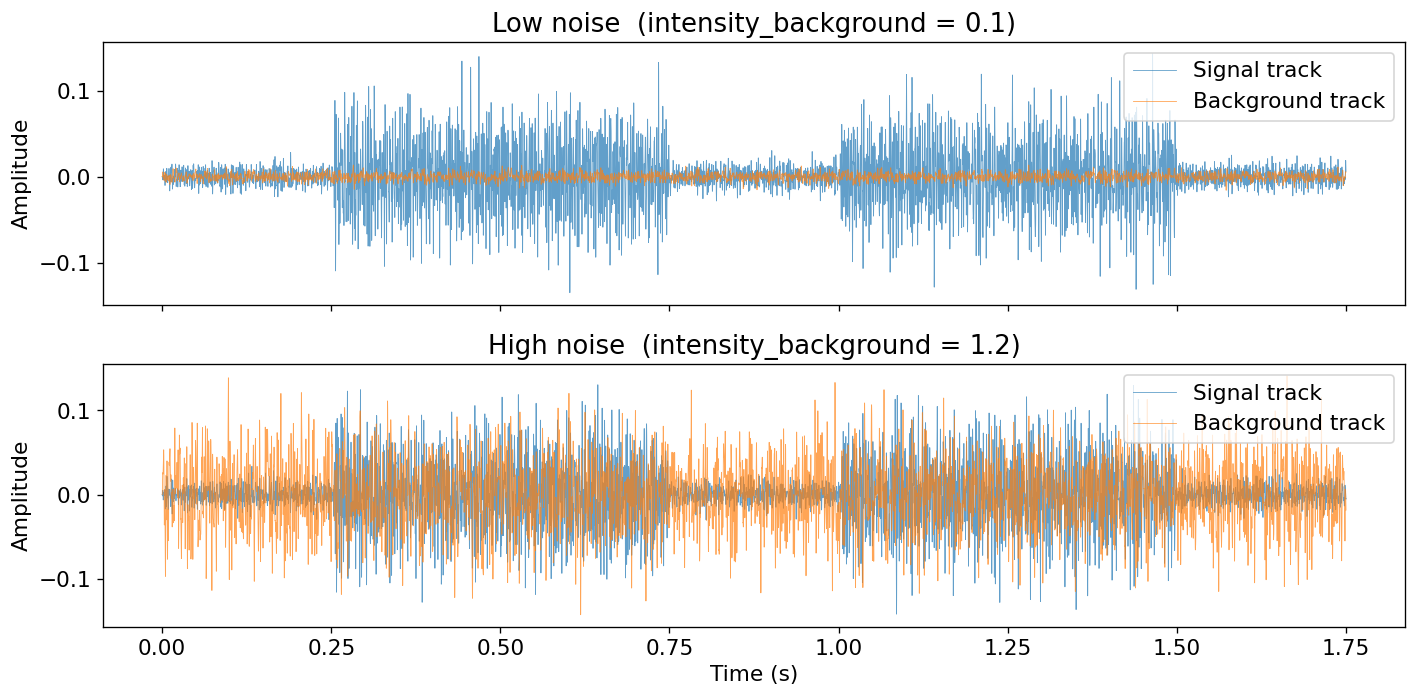

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax, ib, label in zip(axes, [0.1, 1.2], ['Low noise', 'High noise']):
    stim, bg, combined = build_trial(0.5, intensity_background=ib)
    t = np.arange(len(combined)) / SAMPLE_RATE

    ax.plot(t, stim, alpha=0.7, lw=0.5, label='Signal track')
    ax.plot(t, bg,   alpha=0.7, lw=0.5, label='Background track')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{label}  (intensity_background = {ib})')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## 2. Monte-Carlo: actual peak & RMS ratios over many trials
Generate 500 trials per condition and measure the background-to-signal ratio using both peak and RMS, before and after filtering.

In [3]:
N_TRIALS = 10000
conditions = {'Low noise (0.1)': 0.1, 'High noise (1.2)': 1.2}

results = {}
for cond_name, ib in conditions.items():
    peak_ratios = []
    rms_ratios  = []
    for _ in range(N_TRIALS):
        stim, bg, _ = build_trial(0.5, intensity_background=ib)
        peak_ratios.append(np.max(np.abs(bg)) / np.max(np.abs(stim)))
        rms_ratios.append(np.std(bg) / np.std(stim))
    results[cond_name] = {
        'peak': np.array(peak_ratios),
        'rms':  np.array(rms_ratios),
    }

print(f'{"Condition":<22} {"Metric":<8} {"Mean":>8} {"SD":>8} {"CV%":>8}')
print('-' * 56)
for cond, d in results.items():
    for metric in ['peak', 'rms']:
        vals = d[metric]
        cv = 100 * vals.std() / vals.mean()
        print(f'{cond:<22} {metric:<8} {vals.mean():8.4f} {vals.std():8.4f} {cv:7.2f}%')

Condition              Metric       Mean       SD      CV%
--------------------------------------------------------
Low noise (0.1)        peak       0.0980   0.0138   14.10%
Low noise (0.1)        rms        0.1248   0.0108    8.66%
High noise (1.2)       peak       1.1802   0.1697   14.38%
High noise (1.2)       rms        1.5008   0.1305    8.70%


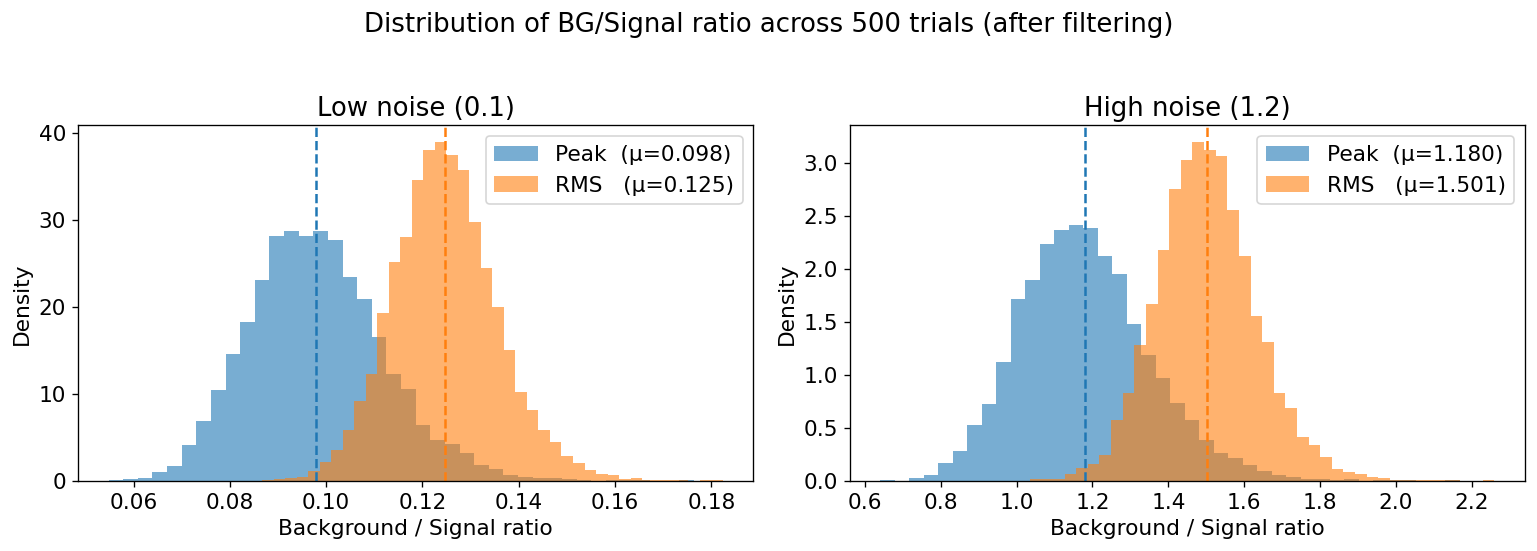

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (cond, d) in zip(axes, results.items()):
    ax.hist(d['peak'], bins=40, alpha=0.6, label=f'Peak  (μ={d["peak"].mean():.3f})', density=True)
    ax.hist(d['rms'],  bins=40, alpha=0.6, label=f'RMS   (μ={d["rms"].mean():.3f})',  density=True)
    ax.axvline(d['peak'].mean(), ls='--', color='C0')
    ax.axvline(d['rms'].mean(),  ls='--', color='C1')
    ax.set_xlabel('Background / Signal ratio')
    ax.set_ylabel('Density')
    ax.set_title(cond)
    ax.legend()

fig.suptitle('Distribution of BG/Signal ratio across 500 trials (after filtering)', y=1.02)
plt.tight_layout()
plt.show()

## 3. Report actual SNR in dB (RMS-based)
This is the number you can cite in the paper.

In [5]:
print('Actual SNR (signal-to-noise ratio) in dB  =  20·log10(RMS_signal / RMS_background)')
print('=' * 72)
for cond, d in results.items():
    snr_db = 20 * np.log10(1.0 / d['rms'])  # signal is denominator=1 after ratio inversion
    print(f'{cond}:  SNR = {snr_db.mean():+.1f} dB  (SD = {snr_db.std():.1f} dB)')

Actual SNR (signal-to-noise ratio) in dB  =  20·log10(RMS_signal / RMS_background)
Low noise (0.1):  SNR = +18.1 dB  (SD = 0.8 dB)
High noise (1.2):  SNR = -3.5 dB  (SD = 0.8 dB)


## 4. How much does peak vs RMS matter?
Compare the nominal ratio you set (peak-based) vs the actual RMS ratio and how much it drifts trial-to-trial.

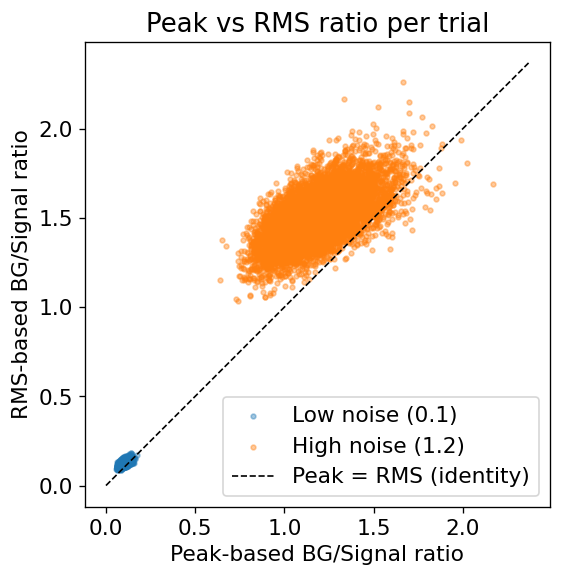

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for cond, d in results.items():
    ax.scatter(d['peak'], d['rms'], s=8, alpha=0.4, label=cond)

lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=1, label='Peak = RMS (identity)')
ax.set_xlabel('Peak-based BG/Signal ratio')
ax.set_ylabel('RMS-based BG/Signal ratio')
ax.set_title('Peak vs RMS ratio per trial')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Trial-to-trial variability: peak vs RMS scaling
Coefficient of variation (lower = more stable across trials).

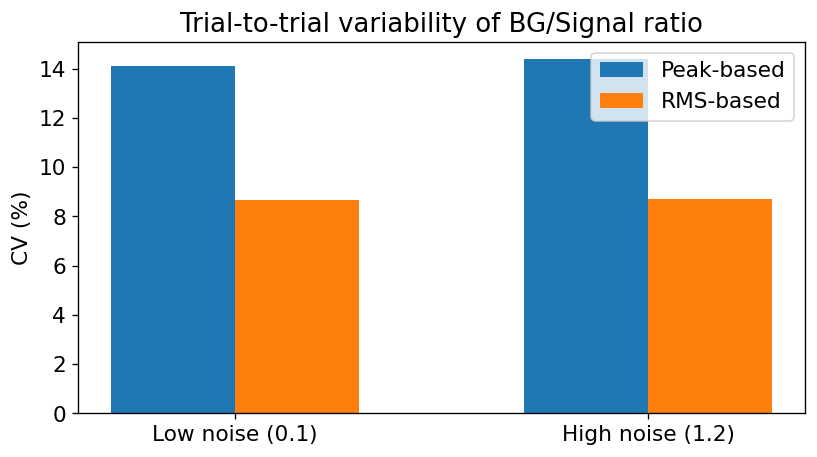

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

conds = list(results.keys())
x = np.arange(len(conds))
w = 0.3

cv_peak = [100 * results[c]['peak'].std() / results[c]['peak'].mean() for c in conds]
cv_rms  = [100 * results[c]['rms'].std()  / results[c]['rms'].mean()  for c in conds]

ax.bar(x - w/2, cv_peak, w, label='Peak-based')
ax.bar(x + w/2, cv_rms,  w, label='RMS-based')
ax.set_xticks(x)
ax.set_xticklabels(conds)
ax.set_ylabel('CV (%)')
ax.set_title('Trial-to-trial variability of BG/Signal ratio')
ax.legend()
plt.tight_layout()
plt.show()

## Summary
Use the mean RMS-based SNR (in dB) from Section 3 to report in the manuscript. If peak and RMS ratios are close and CV is low, the peak-based scaling was a reasonable approximation; if they diverge, note it.

## 6. Energy change from bandpass filtering (what it does to RMS)
This section measures how much each filter changes the RMS of the **signal track** and the **background track**, and how the **BG/Signal RMS ratio** changes from pre-filter to post-filter.

Settings: `maxIntensityBurst=5`, `riseDur=0.005`.

In [8]:
N_TRIALS = 500
conditions = {'Low noise (0.1)': 0.1, 'High noise (1.2)': 1.2}

summary = {}
for cond_name, ib in conditions.items():
    stim_rms_gain = []
    bg_rms_gain = []
    ratio_pre = []
    ratio_post = []
    stim_cf_pre = []
    stim_cf_post = []
    bg_cf_pre = []
    bg_cf_post = []

    for _ in range(N_TRIALS):
        stim_pre, bg_pre, stim_post, bg_post, _ = build_trial_stages(0.5, intensity_background=ib)

        stim_rms_gain.append(rms(stim_post) / (rms(stim_pre) + 1e-12))
        bg_rms_gain.append(rms(bg_post) / (rms(bg_pre) + 1e-12))

        ratio_pre.append(rms(bg_pre) / (rms(stim_pre) + 1e-12))
        ratio_post.append(rms(bg_post) / (rms(stim_post) + 1e-12))

        stim_cf_pre.append(crest_factor(stim_pre))
        stim_cf_post.append(crest_factor(stim_post))
        bg_cf_pre.append(crest_factor(bg_pre))
        bg_cf_post.append(crest_factor(bg_post))

    summary[cond_name] = {
        'stim_rms_gain': np.array(stim_rms_gain),
        'bg_rms_gain': np.array(bg_rms_gain),
        'ratio_pre': np.array(ratio_pre),
        'ratio_post': np.array(ratio_post),
        'stim_cf_pre': np.array(stim_cf_pre),
        'stim_cf_post': np.array(stim_cf_post),
        'bg_cf_pre': np.array(bg_cf_pre),
        'bg_cf_post': np.array(bg_cf_post),
    }

print(f'{"Condition":<22} '
      f'{"RMS gain signal":>14} {"RMS gain bg":>12} '
      f'{"(BG/Sig) RMS pre":>17} {"(BG/Sig) RMS post":>18} '
      f'{"Δratio post/pre":>17}')
print('-' * 104)
for cond, d in summary.items():
    g_stim = d['stim_rms_gain'].mean()
    g_bg = d['bg_rms_gain'].mean()
    r_pre = d['ratio_pre'].mean()
    r_post = d['ratio_post'].mean()
    print(f'{cond:<22} {g_stim:14.3f} {g_bg:12.3f} {r_pre:17.3f} {r_post:18.3f} {r_post/(r_pre+1e-12):17.3f}')

print('\nCrest factor (peak/RMS) means (pre → post):')
print('-' * 72)
for cond, d in summary.items():
    print(
        f"{cond}: signal {d['stim_cf_pre'].mean():.2f} → {d['stim_cf_post'].mean():.2f}, "
        f"bg {d['bg_cf_pre'].mean():.2f} → {d['bg_cf_post'].mean():.2f}"
    )

Condition              RMS gain signal  RMS gain bg  (BG/Sig) RMS pre  (BG/Sig) RMS post   Δratio post/pre
--------------------------------------------------------------------------------------------------------
Low noise (0.1)                 0.171        0.167             0.128              0.126             0.980
High noise (1.2)                0.171        0.167             1.533              1.502             0.980

Crest factor (peak/RMS) means (pre → post):
------------------------------------------------------------------------
Low noise (0.1): signal 5.72 → 5.03, bg 4.48 → 3.93
High noise (1.2): signal 5.69 → 5.03, bg 4.47 → 3.94


## 7. BG/Signal RMS ratio within active intervals only (`test` and `standard`)
Pre/ISI/post are not the perceptual “signal”; the background-to-signal energy comparison should be computed only inside the `test_sound` and `standard_sound` windows.

This section measures:
- BG/Sig RMS ratio and SNR (dB) in `test` and `standard`
- both **pre-filter** and **post-filter**

Settings match the stimulus: `maxIntensityBurst=5`, `riseDur=0.005`.

In [9]:
TEST_DUR = 0.5
STANDARD_DUR = 0.5
PRE_DUR = 0.25
ISI_DUR = 0.25
POST_DUR = 0.25

# Background scaling values used in your study
conditions = {'Low noise (0.1)': 0.1, 'High noise (1.2)': 1.2}

jit_len = int(0.0001 * SAMPLE_RATE)
pre_len = int(PRE_DUR * SAMPLE_RATE)
isi_len = int(ISI_DUR * SAMPLE_RATE)
post_len = int(POST_DUR * SAMPLE_RATE)  # not used directly, but kept for clarity

# Signal burst lengths depend on the raised-cosine rounding
test_len = len(make_signal_interval(TEST_DUR, intensity=MAX_INTENSITY_BURST, rise_dur=RISE_DUR))
std_len  = len(make_signal_interval(STANDARD_DUR, intensity=MAX_INTENSITY_BURST, rise_dur=RISE_DUR))

# Indices of active intervals in the concatenated 1D tracks
# stim = [jit, pre, test, isi, std, post, jit]

test0 = jit_len + pre_len
test1 = test0 + test_len

std0 = test1 + isi_len
std1 = std0 + std_len

print(
    f"Slices (samples): test=[{test0},{test1}) std=[{std0},{std1}) | test_len={test_len} std_len={std_len}"
)

N_TRIALS = 500

def ratio_and_snr(sig, bg):
    # BG/Sig RMS ratio and SNR(dB)=20log10(RMS_sig/RMS_bg)
    sig_r = rms(sig)
    bg_r = rms(bg)
    ratio = bg_r / (sig_r + 1e-12)
    snr_db = 20 * np.log10((sig_r + 1e-12) / (bg_r + 1e-12))
    return ratio, snr_db

print(
    f"\n{'Condition':<16}  "
    f"{'Test ratio':>11} {'Test SNR(dB)':>13}  "
    f"{'Std ratio':>11}  {'Std SNR(dB)':>12}"
)
print('-' * 70)

for cond_name, ib in conditions.items():
    test_ratios_pre = []
    test_snrs_pre = []
    std_ratios_pre = []
    std_snrs_pre = []

    test_ratios_post = []
    test_snrs_post = []
    std_ratios_post = []
    std_snrs_post = []

    for _ in range(N_TRIALS):
        stim_pre, bg_pre, stim_post, bg_post, _ = build_trial_stages(
            TEST_DUR,
            standard_dur=STANDARD_DUR,
            intensity=MAX_INTENSITY_BURST,
            pre_dur=PRE_DUR,
            isi_dur=ISI_DUR,
            post_dur=POST_DUR,
            intensity_background=ib,
        )

        # Pre-filter metrics within active intervals
        tr_pre, ts_pre = ratio_and_snr(stim_pre[test0:test1], bg_pre[test0:test1])
        sr_pre, ss_pre = ratio_and_snr(stim_pre[std0:std1],  bg_pre[std0:std1])

        test_ratios_pre.append(tr_pre)
        test_snrs_pre.append(ts_pre)
        std_ratios_pre.append(sr_pre)
        std_snrs_pre.append(ss_pre)

        # Post-filter metrics within active intervals
        tr_post, ts_post = ratio_and_snr(stim_post[test0:test1], bg_post[test0:test1])
        sr_post, ss_post = ratio_and_snr(stim_post[std0:std1],  bg_post[std0:std1])

        test_ratios_post.append(tr_post)
        test_snrs_post.append(ts_post)
        std_ratios_post.append(sr_post)
        std_snrs_post.append(ss_post)

    # Summarize (post-filter is what you care about perceptually)
    print(
        f"{cond_name:<16}  "
        f"{np.mean(test_ratios_post):>11.3f} {np.mean(test_snrs_post):>13.1f}  "
        f"{np.mean(std_ratios_post):>11.3f} {np.mean(std_snrs_post):>12.1f}"
    )

print("\n(Pre-filter means should be close; post-filter numbers are the key ones.)")

Slices (samples): test=[11029,33078) std=[44103,66152) | test_len=22049 std_len=22049

Condition          Test ratio  Test SNR(dB)    Std ratio   Std SNR(dB)
----------------------------------------------------------------------
Low noise (0.1)         0.096          20.4        0.096         20.4
High noise (1.2)        1.154          -1.2        1.151         -1.2

(Pre-filter means should be close; post-filter numbers are the key ones.)


## RMS and SNR math (explicit)
For a sampled waveform `x[n]` over an interval, the (mean-subtracted) RMS amplitude is:

`RMS(x) = sqrt( mean( (x[n] - mean(x))^2 ) )`

Because power is proportional to amplitude squared, the power ratio is:

`P_sig / P_bg = RMS(sig)^2 / RMS(bg)^2`

So the standard SNR in dB is equivalently:

`SNR_dB = 10 * log10(P_sig/P_bg) = 20 * log10( RMS(sig) / RMS(bg) )`

That’s exactly what the notebook computes in the BG/Sig ratio and then converts to dB.

Window slices: test=[11029,33078) std=[44103,66152) (test_len=22049, std_len=22049)


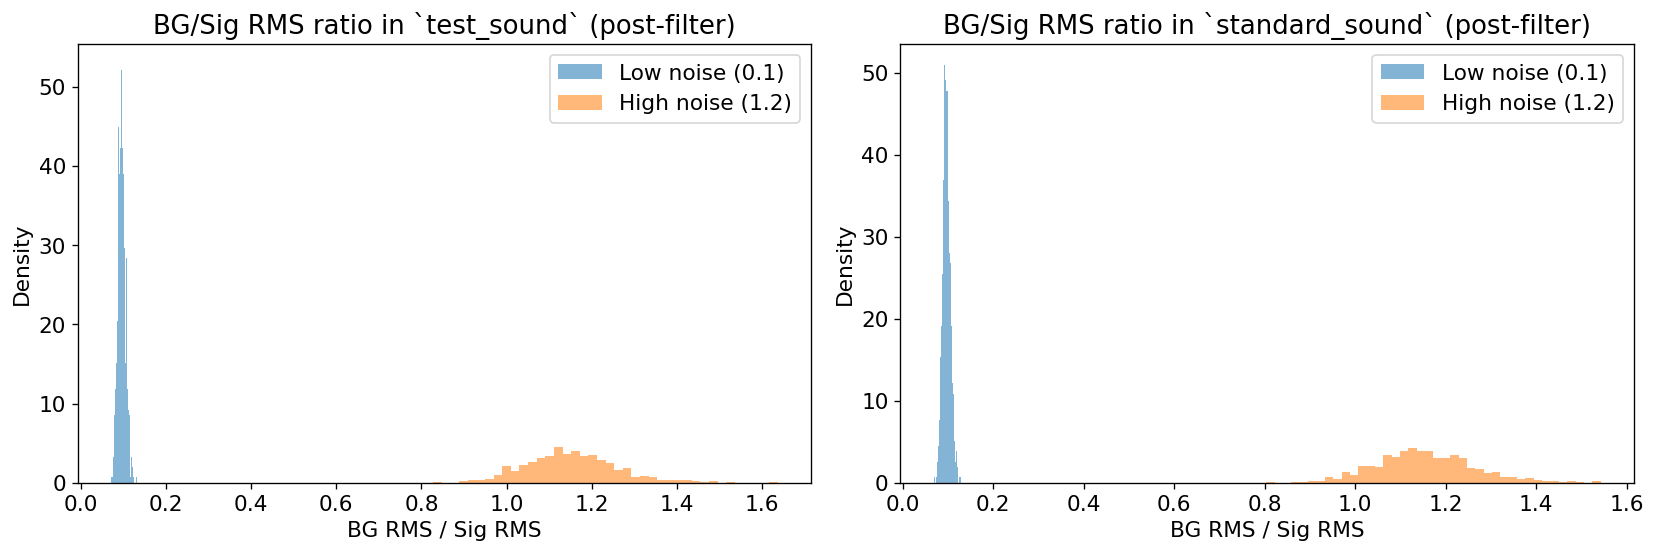

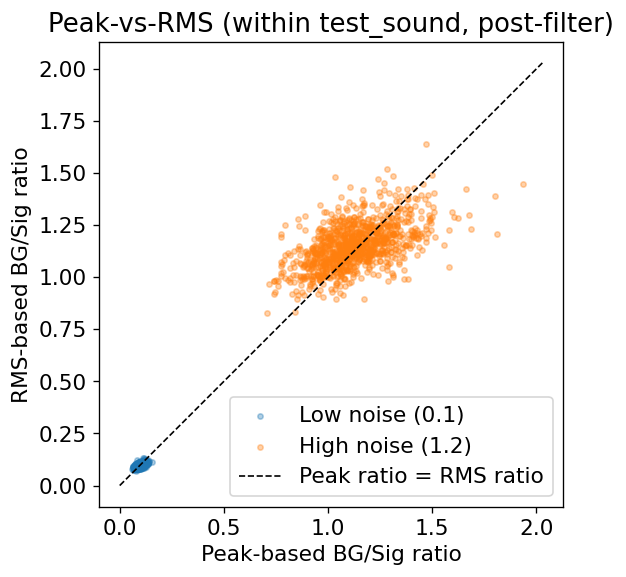


Pearson r between peak-based and RMS-based BG/Sig ratios (post-filter):
  Low noise (0.1) : r = +0.591
  High noise (1.2): r = +0.541
  Overall (test_sound): r = +0.982


In [14]:
# Plots: BG/Sig RMS ratio distributions + peak-vs-RMS scatter (within test & standard windows)

N_TRIALS_PLOTS = 1000
EPS = 1e-12

# Match the section-7 timing used in this notebook
TEST_DUR = 0.5
STANDARD_DUR = 0.5
PRE_DUR = 0.25
ISI_DUR = 0.25
POST_DUR = 0.25

conditions = {'Low noise (0.1)': 0.1, 'High noise (1.2)': 1.2}

jit_len = int(0.0001 * SAMPLE_RATE)
pre_len = int(PRE_DUR * SAMPLE_RATE)
isi_len = int(ISI_DUR * SAMPLE_RATE)

test_len = len(make_signal_interval(TEST_DUR, intensity=MAX_INTENSITY_BURST, rise_dur=RISE_DUR))
std_len  = len(make_signal_interval(STANDARD_DUR, intensity=MAX_INTENSITY_BURST, rise_dur=RISE_DUR))

# stim = [jit, pre, test, isi, std, post, jit]
test0, test1 = jit_len + pre_len, jit_len + pre_len + test_len
std0, std1   = test1 + isi_len, test1 + isi_len + std_len

print(
    f"Window slices: test=[{test0},{test1}) std=[{std0},{std1}) (test_len={test_len}, std_len={std_len})"
)

# Collect metrics (post-filter)
ratio_test = {k: [] for k in conditions}
ratio_std  = {k: [] for k in conditions}
peak_test   = {k: [] for k in conditions}
peak_std    = {k: [] for k in conditions}

for cond_name, ib in conditions.items():
    for _ in range(N_TRIALS_PLOTS):
        stim_pre, bg_pre, stim_post, bg_post, _ = build_trial_stages(
            TEST_DUR,
            standard_dur=STANDARD_DUR,
            intensity=MAX_INTENSITY_BURST,
            pre_dur=PRE_DUR,
            isi_dur=ISI_DUR,
            post_dur=POST_DUR,
            intensity_background=ib,
        )

        # Post-filter only (matches the perceptual comparison)
        sig_test = stim_post[test0:test1]
        bg_test  = bg_post[test0:test1]
        sig_std  = stim_post[std0:std1]
        bg_std   = bg_post[std0:std1]

        rms_sig_test = rms(sig_test)
        rms_bg_test  = rms(bg_test)
        rms_sig_std  = rms(sig_std)
        rms_bg_std   = rms(bg_std)

        rt = rms_bg_test / (rms_sig_test + EPS)
        rs = rms_bg_std  / (rms_sig_std + EPS)

        # Peak ratio for comparison: max(|bg|)/max(|sig|)
        pt = (np.max(np.abs(bg_test)) / (np.max(np.abs(sig_test)) + EPS))
        pt_std = (np.max(np.abs(bg_std)) / (np.max(np.abs(sig_std)) + EPS))

        ratio_test[cond_name].append(rt)
        ratio_std[cond_name].append(rs)
        peak_test[cond_name].append(pt)
        peak_std[cond_name].append(pt_std)

# ---- Plot 1: histograms of BG/Sig RMS ratio ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

bins = 40
colors = {'Low noise (0.1)': 'C0', 'High noise (1.2)': 'C1'}

for cond_name in conditions.keys():
    axes[0].hist(ratio_test[cond_name], bins=bins, alpha=0.55, density=True,
                 color=colors[cond_name], label=cond_name)
    axes[1].hist(ratio_std[cond_name], bins=bins, alpha=0.55, density=True,
                 color=colors[cond_name], label=cond_name)

axes[0].set_title('BG/Sig RMS ratio in `test_sound` (post-filter)')
axes[0].set_xlabel('BG RMS / Sig RMS')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].set_title('BG/Sig RMS ratio in `standard_sound` (post-filter)')
axes[1].set_xlabel('BG RMS / Sig RMS')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---- Plot 2: peak-vs-RMS scatter within test_sound ----
fig, ax = plt.subplots(figsize=(7.5, 5))

for cond_name in conditions.keys():
    rt = np.array(ratio_test[cond_name])
    pt = np.array(peak_test[cond_name])
    ax.scatter(pt, rt, s=10, alpha=0.35, color=colors[cond_name], label=cond_name)

# Identity line
lims = [0, max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=1, label='Peak ratio = RMS ratio')

ax.set_xlabel('Peak-based BG/Sig ratio')
ax.set_ylabel('RMS-based BG/Sig ratio')
ax.set_title('Peak-vs-RMS (within test_sound, post-filter)')
ax.legend()
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# ---- Pearson correlations between peak-based and RMS-based ratios ----
print('\nPearson r between peak-based and RMS-based BG/Sig ratios (post-filter):')
for cond_name in conditions.keys():
    x = np.array(peak_test[cond_name])
    y = np.array(ratio_test[cond_name])
    r = float(np.corrcoef(x, y)[0, 1])
    print(f'  {cond_name:<16}: r = {r:+.3f}')

# Overall (both conditions combined), within test_sound
all_x = np.concatenate([np.array(peak_test[c]) for c in conditions.keys()])
all_y = np.concatenate([np.array(ratio_test[c]) for c in conditions.keys()])
r_all = float(np.corrcoef(all_x, all_y)[0, 1])
print(f'  Overall (test_sound): r = {r_all:+.3f}')


In [15]:

# Within standard_sound
print('Pearson r (standard_sound) between peak-based and RMS-based BG/Sig ratios (post-filter):')
for cond_name in conditions.keys():
    x = np.array(peak_std[cond_name])
    y = np.array(ratio_std[cond_name])
    r = float(np.corrcoef(x, y)[0, 1])
    print(f'  {cond_name:<16}: r = {r:+.3f}')

    # INSERT_YOUR_CODE
    # ---- Statistical significance test of correlation: test if r significantly differs from 0 ----
    from scipy.stats import pearsonr

    print('\nSignificance tests for Pearson r (test_sound, combined conditions):')
    r_val, p_val = pearsonr(all_x, all_y)
    print(f'Combined/Overall: r = {r_val:+.3f}, p = {p_val:.2e} (N = {len(all_x)})')

    print('\nSignificance tests for Pearson r by condition (test_sound):')
    for cond_name in conditions.keys():
        x = np.array(peak_test[cond_name])
        y = np.array(ratio_test[cond_name])
        r_val, p_val = pearsonr(x, y)
        print(f'  {cond_name:<16}: r = {r_val:+.3f}, p = {p_val:.2e} (N = {len(x)})')

    print('\nSignificance tests for Pearson r by condition (standard_sound):')
    for cond_name in conditions.keys():
        x = np.array(peak_std[cond_name])
        y = np.array(ratio_std[cond_name])
        r_val, p_val = pearsonr(x, y)
        print(f'  {cond_name:<16}: r = {r_val:+.3f}, p = {p_val:.2e} (N = {len(x)})')



Pearson r (standard_sound) between peak-based and RMS-based BG/Sig ratios (post-filter):
  Low noise (0.1) : r = +0.563

Significance tests for Pearson r (test_sound, combined conditions):
Combined/Overall: r = +0.982, p = 0.00e+00 (N = 2000)

Significance tests for Pearson r by condition (test_sound):
  Low noise (0.1) : r = +0.591, p = 3.95e-95 (N = 1000)
  High noise (1.2): r = +0.541, p = 5.88e-77 (N = 1000)

Significance tests for Pearson r by condition (standard_sound):
  Low noise (0.1) : r = +0.563, p = 8.87e-85 (N = 1000)
  High noise (1.2): r = +0.559, p = 3.96e-83 (N = 1000)
  High noise (1.2): r = +0.559

Significance tests for Pearson r (test_sound, combined conditions):
Combined/Overall: r = +0.982, p = 0.00e+00 (N = 2000)

Significance tests for Pearson r by condition (test_sound):
  Low noise (0.1) : r = +0.591, p = 3.95e-95 (N = 1000)
  High noise (1.2): r = +0.541, p = 5.88e-77 (N = 1000)

Significance tests for Pearson r by condition (standard_sound):
  Low noise (0.

In [17]:
# INSERT_YOUR_CODE

# ---- Mean bias check: test_sound, post bandpass, maxIntensityBurst=5, riseDur=0.005, N=1000 ----
# Compute mean of peak_test and ratio_test for each condition
print("Mean peak-based and RMS-based ratio (test_sound, post bandpass):")
mean_peak_test = {c: np.mean(peak_test[c]) for c in conditions.keys()}
mean_ratio_test = {c: np.mean(ratio_test[c]) for c in conditions.keys()}

for cond_name in conditions.keys():
    print(f"  {cond_name:<16}: mean peak = {mean_peak_test[cond_name]:.3f}, mean RMS = {mean_ratio_test[cond_name]:.3f}")

# Compute mean over all conditions (pooled)
all_peak_test = np.concatenate([np.array(peak_test[c]) for c in conditions.keys()])
all_ratio_test = np.concatenate([np.array(ratio_test[c]) for c in conditions.keys()])
mean_peak_all = np.mean(all_peak_test)
mean_ratio_all = np.mean(all_ratio_test)
print(f"\n  Overall (test_sound): mean peak = {mean_peak_all:.3f}, mean RMS = {mean_ratio_all:.3f}")

# Bias: mean_peak - mean_rms
for cond_name in conditions.keys():
    bias = mean_peak_test[cond_name] - mean_ratio_test[cond_name]
    print(f"  {cond_name:<16}: mean bias (peak - RMS) = {bias:.4f}")
overall_bias = mean_peak_all - mean_ratio_all
print(f"\n  Overall (test_sound): mean bias (peak - RMS) = {overall_bias:.4f}")





Mean peak-based and RMS-based ratio (test_sound, post bandpass):
  Low noise (0.1) : mean peak = 0.095, mean RMS = 0.097
  High noise (1.2): mean peak = 1.127, mean RMS = 1.151

  Overall (test_sound): mean peak = 0.611, mean RMS = 0.624
  Low noise (0.1) : mean bias (peak - RMS) = -0.0018
  High noise (1.2): mean bias (peak - RMS) = -0.0233

  Overall (test_sound): mean bias (peak - RMS) = -0.0125
